<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Health Insurance Costs Prediction**

---

In [1]:
import sys
!{sys.executable} -m pip install streamlit

In [2]:
import sys
!{sys.executable} -m pip install joblib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Health Insurance Costs Prediction - Dataset.csv')
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [5]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [6]:
df.tail()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87
1339,1340,30.0,female,47.4,101,No,0,Yes,southeast,63770.43


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [8]:
df.shape

(1340, 10)

In [9]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [10]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01


In [11]:
print(df.duplicated().sum())

0


In [12]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [13]:
print(df.isna().sum().sum())

8


In [14]:
df.dropna(inplace = True)

In [15]:
print(df.isna().sum().sum())

0


In [16]:
df.describe(include = 'all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


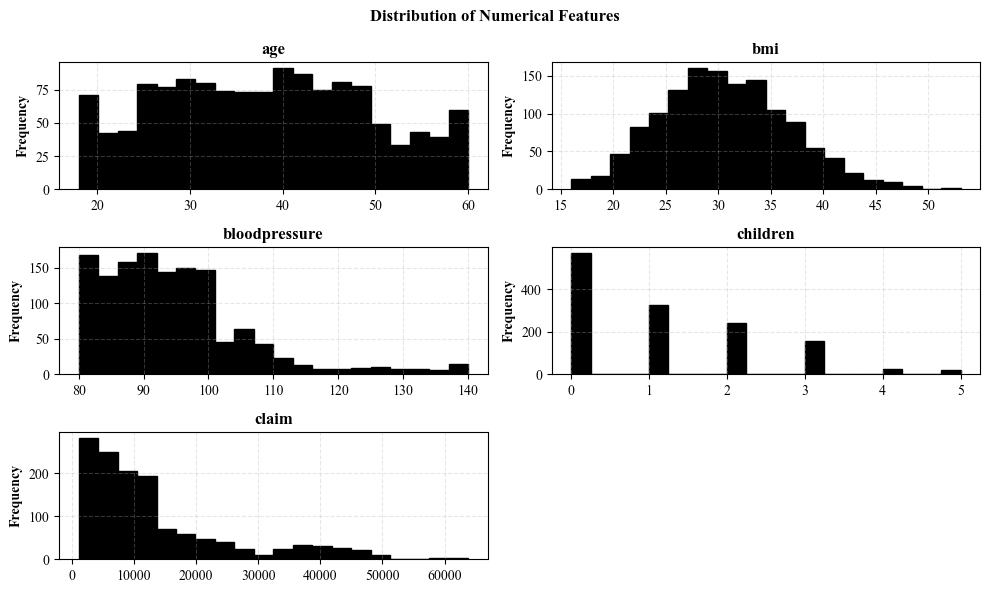

In [17]:
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

numerical_cols = ['age', 'bmi', 'bloodpressure', 'children', 'claim']

axes = df[numerical_cols].hist(bins = 20, figsize = (10, 6), color = 'black', edgecolor = 'black')
plt.suptitle('Distribution of Numerical Features', fontweight = 'bold', fontsize = 12)

for ax in axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontweight = 'bold')
    ax.set_ylabel('Frequency', fontweight = 'bold')
    ax.set_title(ax.get_title(), fontweight = 'bold', fontsize = 12)
    ax.grid(True, linestyle = '--', alpha = 0.3)
    
plt.tight_layout()
plt.show()

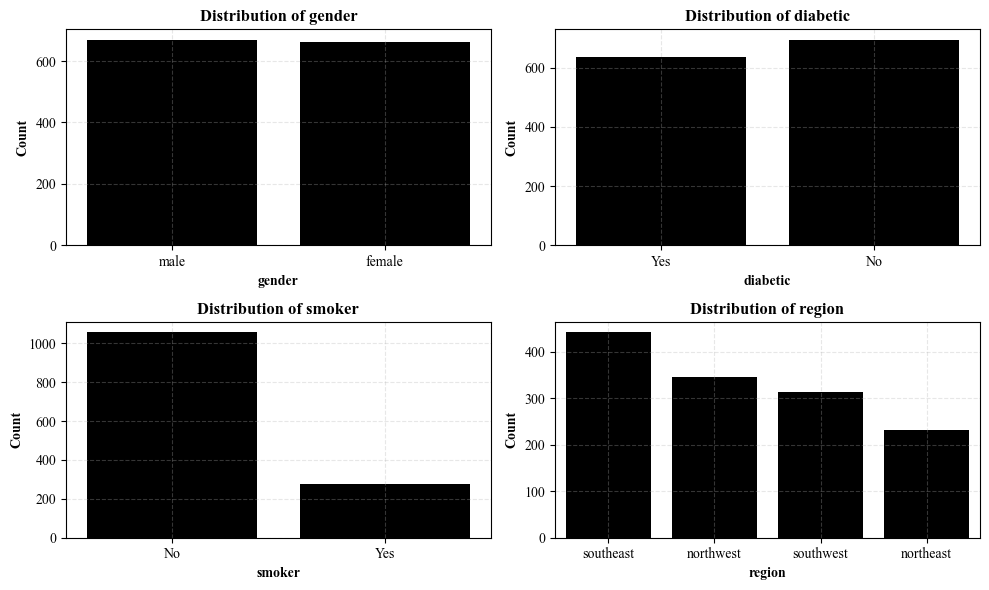

In [18]:
categorical_cols = ['gender', 'diabetic', 'smoker', 'region']

fig, axes = plt.subplots(2, 2, figsize = (10, 6))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data = df, x = col, ax = axes[i], color = 'black')
    axes[i].set_title(f'Distribution of {col}', fontweight = 'bold', fontsize = 12)
    axes[i].set_xlabel(col, fontweight = 'bold')
    axes[i].set_ylabel('Count', fontweight = 'bold')
    axes[i].grid(True, linestyle = '--', alpha = 0.3)

plt.tight_layout()
plt.show()

In [19]:
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

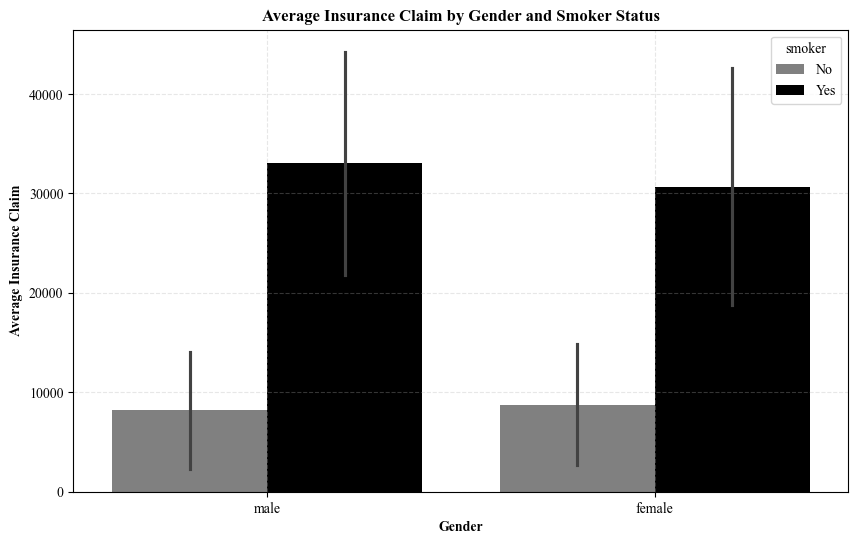

In [20]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(data = df, x = 'gender', y = 'claim', hue = 'smoker', estimator = 'mean',
            errorbar = 'sd', palette = {'Yes': 'black', 'No': 'grey'}, ax = ax)
ax.set_title('Average Insurance Claim by Gender and Smoker Status', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Gender', fontweight = 'bold')
ax.set_ylabel('Average Insurance Claim', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [21]:
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


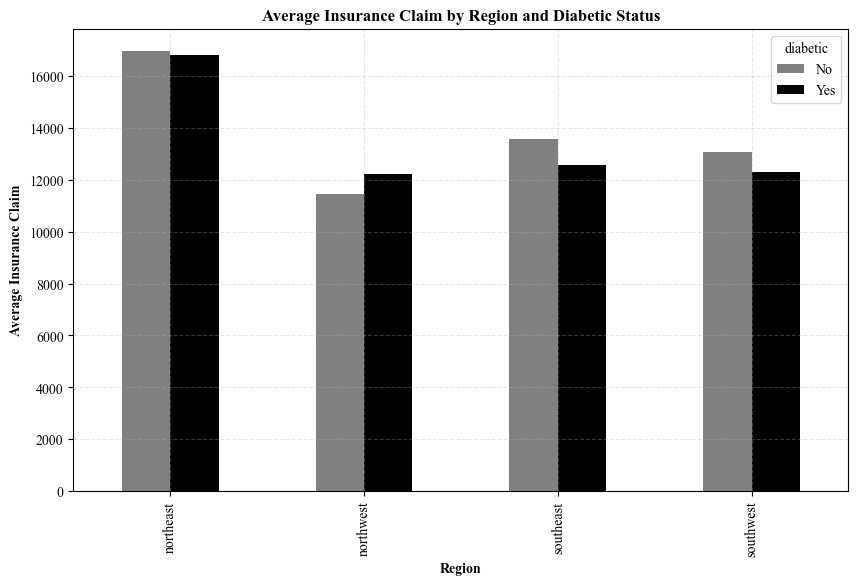

In [22]:
fig, ax = plt.subplots(figsize = (10, 6))
pivot_region_diabetic.plot(kind = 'bar', color = ['grey', 'black'], ax = ax)
ax.set_title('Average Insurance Claim by Region and Diabetic Status', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Region', fontweight = 'bold')
ax.set_ylabel('Average Insurance Claim', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [23]:
pivot_region_smoker = pd.pivot_table(df, values = 'claim', index = 'region', columns = 'smoker', aggfunc = 'mean')
pivot_region_smoker

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [24]:
pivot_children_diabetic = pd.pivot_table(df, values = 'claim', index = 'children', columns = 'diabetic', aggfunc = 'mean')
pivot_children_diabetic

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [25]:
numerical_cols

['age', 'bmi', 'bloodpressure', 'children', 'claim']

In [26]:
df[numerical_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


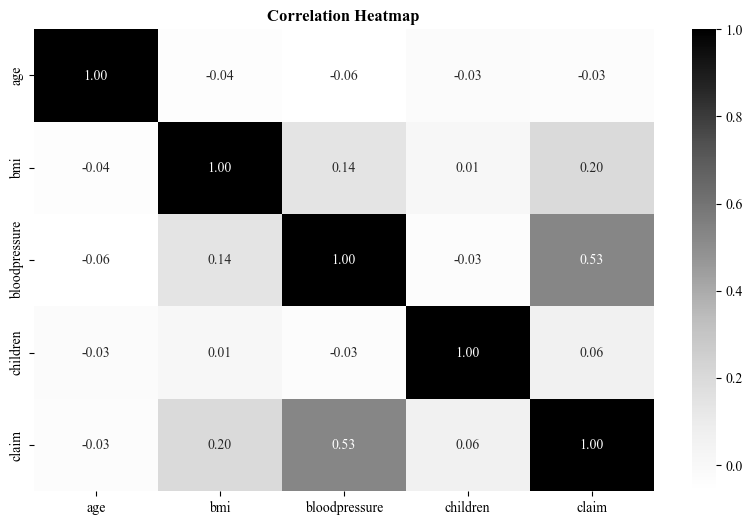

In [27]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(df[numerical_cols].corr(), annot = True, cmap = 'Greys', fmt = '.2f', ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('', fontweight = 'bold')
ax.set_ylabel('', fontweight = 'bold')

plt.show()

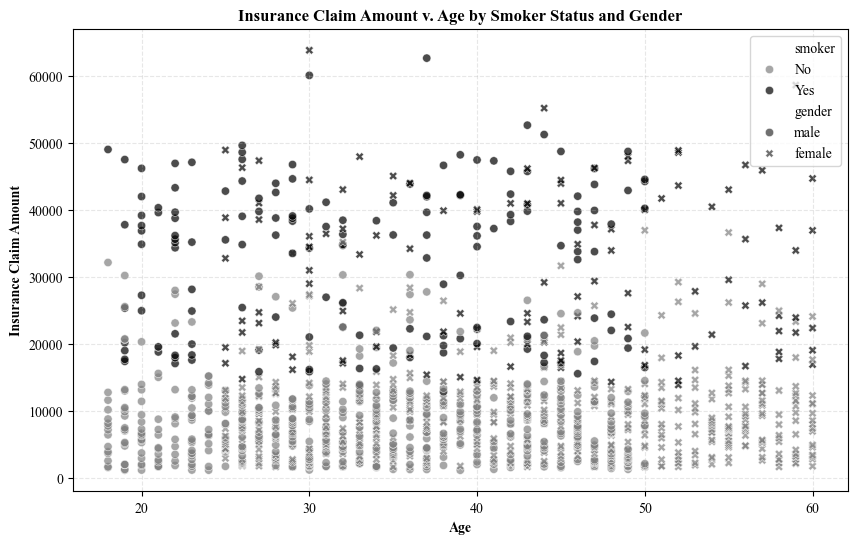

In [28]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data = df, x = 'age', y = 'claim', hue = 'smoker', style = 'gender', 
                alpha = 0.7, palette = {'Yes': 'black', 'No': 'grey'}, ax = ax)
ax.set_title('Insurance Claim Amount v. Age by Smoker Status and Gender', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Age', fontweight = 'bold')
ax.set_ylabel('Insurance Claim Amount', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

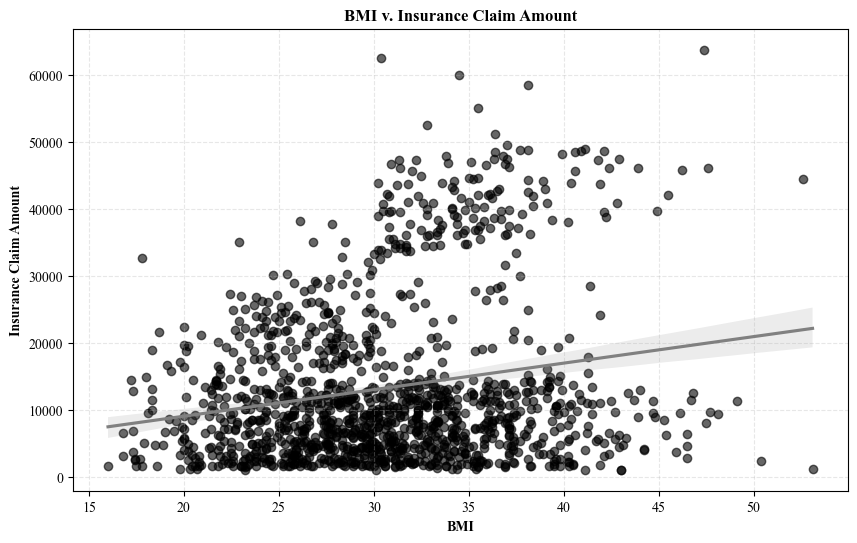

In [29]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.regplot(data = df, x = 'bmi', y = 'claim', scatter_kws = {'alpha': 0.6, 'color': 'black'},
            line_kws = {'color': 'grey'}, ax = ax)
ax.set_title('BMI v. Insurance Claim Amount', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('BMI', fontweight = 'bold')
ax.set_ylabel('Insurance Claim Amount', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

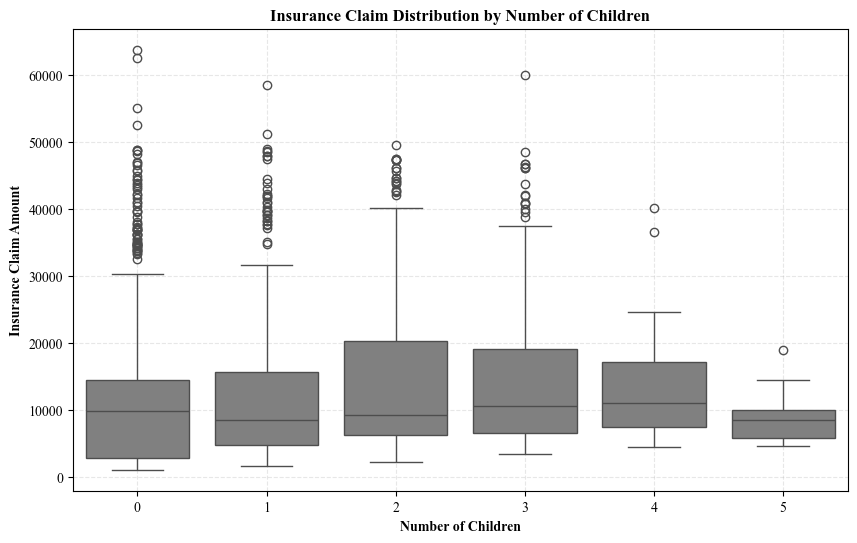

In [30]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(data = df, x = 'children', y = 'claim', color = 'grey', ax = ax)
ax.set_title('Insurance Claim Distribution by Number of Children', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Number of Children', fontweight = 'bold')
ax.set_ylabel('Insurance Claim Amount', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [31]:
df['age_group'] = pd.cut(df['age'], bins = [0, 18, 30, 45, 60, 100], labels = ['<18', '18-30', '31-45', '46-60', '60+'])
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [32]:
df['age_group'].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

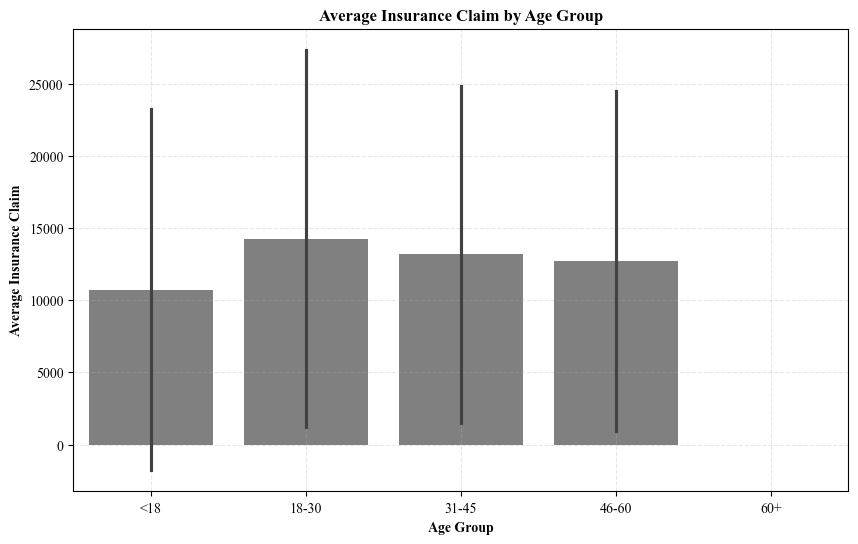

In [33]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(data = df, x = 'age_group', y = 'claim', estimator = 'mean', errorbar = 'sd', color = 'grey', ax = ax)
ax.set_title('Average Insurance Claim by Age Group', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Age Group', fontweight = 'bold')
ax.set_ylabel('Average Insurance Claim', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [34]:
df['bmi_category'] = pd.cut(df['bmi'], bins = [0, 18.5, 24.9, 29.9, 100], labels = ['Underweight', 'Normal', 'Overweight', 'Obese'])
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group,bmi_category
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45,Normal
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30,Obese
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30,Obese
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30,Obese
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30,Obese
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45,Obese
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60,Obese
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30,Obese
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45,Obese


In [35]:
df['bmi_category'].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

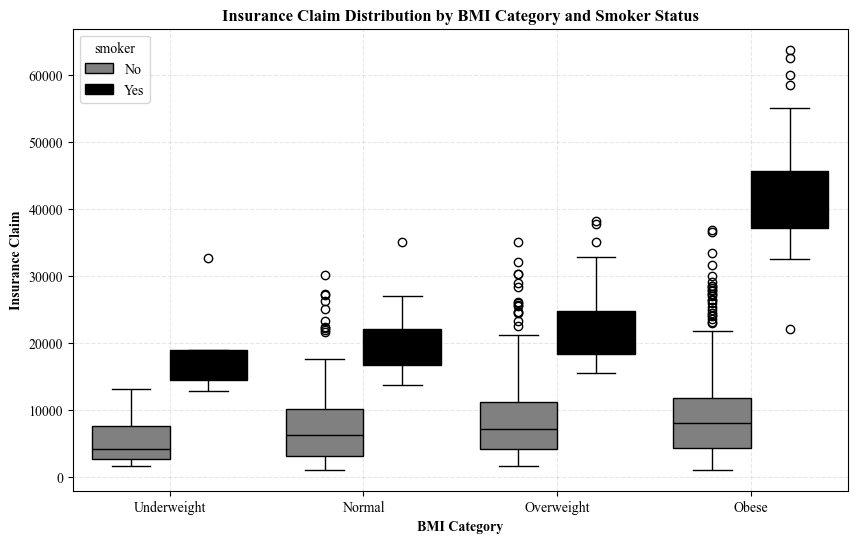

In [36]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(data = df, x = 'bmi_category', y = 'claim', hue = 'smoker',
            palette = {'Yes': 'black', 'No': 'grey'}, ax = ax)
ax.set_title('Insurance Claim Distribution by BMI Category and Smoker Status', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('BMI Category', fontweight = 'bold')
ax.set_ylabel('Insurance Claim', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [39]:
region_stats = df.groupby('region').agg(smoker_rate = ('smoker', lambda x: (x == 'Yes').mean() * 100), 
                                        mean_claim = ('claim', 'mean')).reset_index()
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


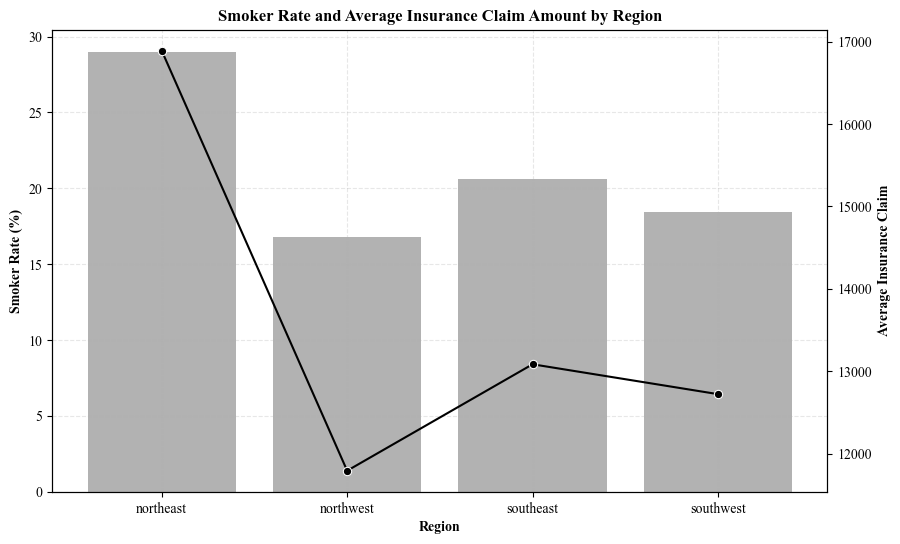

In [42]:
fig, ax1 = plt.subplots(figsize = (10, 6))
sns.barplot(data = region_stats, x = 'region', y = 'smoker_rate', ax = ax1, color = 'grey', alpha = 0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_stats, x = 'region', y = 'mean_claim', ax = ax2, color = 'black', marker = 'o')
ax1.set_title('Smoker Rate and Average Insurance Claim Amount by Region', fontweight = 'bold', fontsize = 12)
ax1.set_xlabel('Region', fontweight = 'bold')
ax1.set_ylabel('Smoker Rate (%)', fontweight = 'bold')
ax2.set_ylabel('Average Insurance Claim', fontweight = 'bold')
ax1.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [44]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [45]:
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y = df['claim']

In [46]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [47]:
y

0       1121.87
1       1131.51
7       1146.80
8       1149.40
9       1163.46
         ...   
1335   55135.40
1336   58571.07
1337   60021.40
1338   62592.87
1339   63770.43
Name: claim, Length: 1332, dtype: float64

In [51]:
import warnings
warnings.filterwarnings('ignore')

categorical_cols = ['gender', 'diabetic', 'smoker']

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    joblib.dump(le, f'Health Insurance Costs Prediction - Label Encoder {col}.pkl')

In [52]:
X.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0


In [53]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [56]:
numerical_cols = ['age', 'bmi', 'bloodpressure', 'children']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.fit_transform(X_test[numerical_cols])

joblib.dump(scaler, 'Health Insurance Costs Prediction - Scaler.pkl')

['Health Insurance Costs Prediction - Scaler.pkl']

In [59]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1065, 7) (267, 7) (1065,) (267,)


In [60]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [61]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    return{'R2': r2, 'MAE': mae, 'RMSE': rmse}

In [62]:
results = {}

In [64]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = evaluate_model(lr, X_train, X_test, y_train, y_test)

best_poly_model = None
best_poly_score = -np.inf
for degree in [2, 3]:
    poly = PolynomialFeatures(degree = degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)
    score = poly_lr.score(X_test_poly, y_test)
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)
degree, poly, poly_lr = best_poly_model
results[f'Polynomial Regression (Degree: {degree})'] = evaluate_model(poly_lr, 
                                                                      poly.fit_transform(X_train),
                                                                      poly.transform(X_test),
                                                                      y_train,
                                                                      y_test)

rf = RandomForestRegressor()
rf_params = {'n_estimators': [100, 200],
             'max_depth': [None, 10, 20],
             'min_samples_split': [2, 5],
             'min_samples_leaf': [1, 2]}
rf_grid = GridSearchCV(rf, rf_params, cv = 3, scoring = 'r2', n_jobs = -1, verbose = 0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
results['Random Forest'] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)
print('Random Forest Best Parameters:', rf_grid.best_params_)

svr = SVR()
svr_params = {'kernel': ['rbf', 'poly', 'linear'],
              'C': [1, 10, 50],
              'epsilon': [0.1, 0.2, 0.5],
              'degree': [2, 3]}
svr_grid = GridSearchCV(svr, svr_params, cv = 3, scoring = 'r2', n_jobs = -1, verbose = 0)
svr_grid.fit(X_train, y_train)
best_svr = svr_grid.best_estimator_
results['SVR'] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)
print('SVR Best Parameters:', svr_grid.best_params_)

xgb = XGBRegressor(objective = 'reg:squarederror')
xgb_params = {'n_estimators': [100, 200],
              'max_depth': [3, 5, 7],
              'learning_rate': [0.01, 0.05, 0.1],
              'subsample': [0.8, 1.0]}
xgb_grid = GridSearchCV(xgb, xgb_params, cv = 3, scoring = 'r2', n_jobs = -1, verbose = 0)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
results['XGBoost'] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)
print('XGBoost Best Parameters:', xgb_grid.best_params_)

Random Forest Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
SVR Best Parameters: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [66]:
results_df = pd.DataFrame(results).T.sort_values(by = 'R2', ascending = False)
results_df

,R2,MAE,RMSE
XGBoost,0.81,3949.73,5162.99
Random Forest,0.78,4288.85,5503.01
Polynomial Regression (Degree: 2),0.76,4468.51,5744.73
Linear Regression,0.74,4824.60,6079.00
SVR,0.52,5764.37,8192.48


In [68]:
models = {'Linear Regression': lr,
          'Polynomial Regression': poly_lr,
          'Random Forest': best_rf,
          'SVR': best_svr,
          'XGBoost': best_xgb}

In [70]:
best_r2 = results_df['R2'].max()
print(best_r2)

0.8089983389704207


In [71]:
top_model = results_df[results_df['R2'] == best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.81,3949.73,5162.99


In [72]:
best_model = models[top_model.index[0]]
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [73]:
joblib.dump(best_model, 'Health Insurance Costs Prediction - XGBoost Model.pkl')

['Health Insurance Costs Prediction - XGBoost Model.pkl']